In [1]:
import pandas as pd

In [2]:
md_feat_1c2x = pd.read_csv('./dssr_ml_features_complete.csv')

In [3]:
shape_1m7 = pd.read_csv('./1C2X.shape', header=None, names=['reactivity'])

In [ ]:
shape_1m7 = pd.read_csv('./PDB_1M7_noSAM_noMg_T30C_all_RNAPDB022.shape', sep='\t', header=None, names=['position', 'reactivity'])

In [ ]:
shape_1m7.set_index('position', inplace=True)  # Set position as index after loading

In [4]:
shape_1m7

,reactivity
0,0.000000
1,0.254992
2,0.101382
3,0.052227
4,0.000000
...,...
115,0.000000
116,0.254992
117,0.718894
118,2.718894


In [5]:
md_feat_1c2x

,nucleotide,fraction_paired,fraction_wc_paired,fraction_non_wc_paired,fraction_unpaired,fraction_in_helix,fraction_in_stem,fraction_in_hairpin,fraction_in_internal_loop,fraction_in_junction,...,theta_min,theta_max,phase_angle_mean,phase_angle_std,phase_angle_min,phase_angle_max,amplitude_mean,amplitude_std,amplitude_min,amplitude_max
0,U1,0.804797,0.734177,0.123251,0.195203,0.756163,0.686875,0.0,0.001999,0.0,...,NaN,NaN,67.857262,97.493978,0.033,359.951,39.667097,5.669760,11.783,59.212
1,G2,0.999334,0.997335,0.003331,0.000666,0.999334,0.992672,0.0,0.001999,0.0,...,-176.620,177.487,84.537436,135.973631,0.002,359.974,38.806781,5.246411,19.346,59.097
2,C3,1.000000,1.000000,0.003331,0.000000,1.000000,0.999334,0.0,0.001999,0.0,...,-179.875,-111.523,45.274829,93.515968,0.002,359.905,40.027119,4.928269,19.287,54.295
3,C4,1.000000,1.000000,0.007328,0.000000,1.000000,1.000000,0.0,0.086609,0.0,...,-179.309,179.471,34.890535,70.160539,0.015,359.981,40.314075,4.912286,21.989,52.792
4,U5,0.999334,0.996669,0.012658,0.000666,0.999334,0.913391,0.0,0.086609,0.0,...,-179.554,179.580,31.732833,62.930794,0.008,359.951,40.445165,5.125346,19.331,54.112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,G116,1.000000,1.000000,0.001999,0.000000,1.000000,1.000000,0.0,0.086609,0.0,...,-176.008,164.134,49.323183,104.409666,0.021,359.929,41.159900,4.605690,21.945,56.971
116,G117,1.000000,1.000000,0.000666,0.000000,1.000000,0.999334,0.0,0.001999,0.0,...,-176.752,179.354,63.908957,119.235112,0.000,359.989,39.612044,4.977683,21.534,52.910
117,C118,0.999334,0.997335,0.001999,0.000666,0.999334,0.992672,0.0,0.001999,0.0,...,-179.684,179.923,32.911791,70.096470,0.055,359.946,40.569602,4.902573,15.838,57.334
118,A119,0.712192,0.703531,0.008661,0.287808,0.710193,0.686875,0.0,0.001999,0.0,...,-179.842,179.690,56.282895,109.494348,0.044,359.958,38.327668,5.265202,13.286,52.623


In [6]:
numeric_feats = md_feat_1c2x.drop(['nucleotide'], axis=1)

In [7]:
numeric_feats

,fraction_paired,fraction_wc_paired,fraction_non_wc_paired,fraction_unpaired,fraction_in_helix,fraction_in_stem,fraction_in_hairpin,fraction_in_internal_loop,fraction_in_junction,puckering_C3_endo,...,theta_min,theta_max,phase_angle_mean,phase_angle_std,phase_angle_min,phase_angle_max,amplitude_mean,amplitude_std,amplitude_min,amplitude_max
0,0.804797,0.734177,0.123251,0.195203,0.756163,0.686875,0.0,0.001999,0.0,0.586276,...,NaN,NaN,67.857262,97.493978,0.033,359.951,39.667097,5.669760,11.783,59.212
1,0.999334,0.997335,0.003331,0.000666,0.999334,0.992672,0.0,0.001999,0.0,0.760826,...,-176.620,177.487,84.537436,135.973631,0.002,359.974,38.806781,5.246411,19.346,59.097
2,1.000000,1.000000,0.003331,0.000000,1.000000,0.999334,0.0,0.001999,0.0,0.870087,...,-179.875,-111.523,45.274829,93.515968,0.002,359.905,40.027119,4.928269,19.287,54.295
3,1.000000,1.000000,0.007328,0.000000,1.000000,1.000000,0.0,0.086609,0.0,0.886076,...,-179.309,179.471,34.890535,70.160539,0.015,359.981,40.314075,4.912286,21.989,52.792
4,0.999334,0.996669,0.012658,0.000666,0.999334,0.913391,0.0,0.086609,0.0,0.882079,...,-179.554,179.580,31.732833,62.930794,0.008,359.951,40.445165,5.125346,19.331,54.112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1.000000,1.000000,0.001999,0.000000,1.000000,1.000000,0.0,0.086609,0.0,0.884077,...,-176.008,164.134,49.323183,104.409666,0.021,359.929,41.159900,4.605690,21.945,56.971
116,1.000000,1.000000,0.000666,0.000000,1.000000,0.999334,0.0,0.001999,0.0,0.830113,...,-176.752,179.354,63.908957,119.235112,0.000,359.989,39.612044,4.977683,21.534,52.910
117,0.999334,0.997335,0.001999,0.000666,0.999334,0.992672,0.0,0.001999,0.0,0.904064,...,-179.684,179.923,32.911791,70.096470,0.055,359.946,40.569602,4.902573,15.838,57.334
118,0.712192,0.703531,0.008661,0.287808,0.710193,0.686875,0.0,0.001999,0.0,0.834111,...,-179.842,179.690,56.282895,109.494348,0.044,359.958,38.327668,5.265202,13.286,52.623


In [8]:
pearson_corr = numeric_feats.corrwith(shape_1m7['reactivity'], method='pearson')

/home/saeid/.conda/envs/mdtraj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/saeid/.conda/envs/mdtraj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [9]:
spearman_corr = numeric_feats.corrwith(shape_1m7['reactivity'], method='spearman')

/home/saeid/.conda/envs/mdtraj/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


In [10]:
corr_df = pd.DataFrame({
    'pearson_r': pearson_corr,
    'spearman_rho': spearman_corr
}).sort_values(by='pearson_r', key=lambda s: s.abs(), ascending=False)

print(corr_df.head(10))

                    pearson_r  spearman_rho
chi_mean             0.488069      0.537757
fraction_in_helix   -0.470325     -0.552258
glyco_bond_other     0.439100      0.416623
puckering_C3_endo   -0.436113     -0.548025
amplitude_std        0.432107      0.469018
fraction_paired     -0.428252     -0.501270
fraction_unpaired    0.428252      0.501270
delta_std            0.420580      0.462277
fraction_wc_paired  -0.412722     -0.511532
fraction_in_stem    -0.409870     -0.508855


In [11]:
corr_df.to_csv('correlationsV2.csv')

/home/saeid/.conda/envs/mdtraj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/saeid/.conda/envs/mdtraj/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


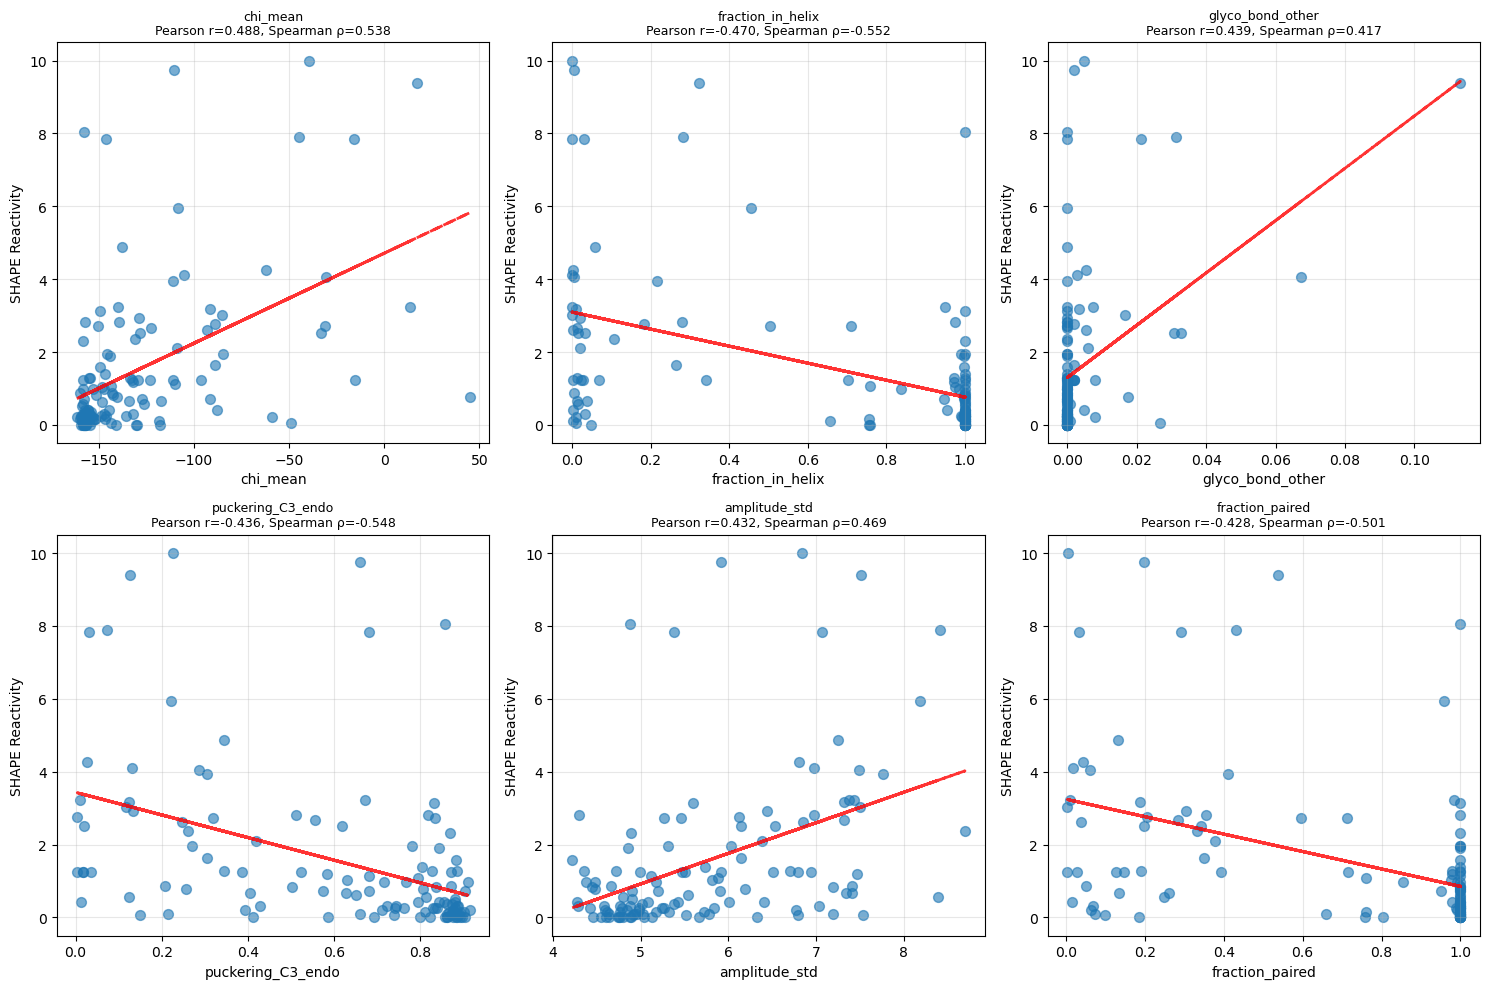

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Get top features (excluding self-correlation)
pearson_corr = numeric_feats.corrwith(shape_1m7['reactivity'], method='pearson')
top_features = pearson_corr.abs().sort_values(ascending=False).head(6).index

# Create scatter plots for top 6 features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    x = numeric_feats[feature]
    y = shape_1m7['reactivity']
    
    # Scatter plot
    ax.scatter(x, y, alpha=0.6, s=50)
    
    # Add regression line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(x, p(x), "r--", alpha=0.8, linewidth=2)
    
    # Calculate correlations
    r, p_val = pearsonr(x, y)
    rho, _ = spearmanr(x, y)
    
    # Labels
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('SHAPE Reactivity', fontsize=10)
    ax.set_title(f'{feature}\nPearson r={r:.3f}, Spearman ρ={rho:.3f}', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('correlation_plotsV2.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Get top features
pearson_corr = numeric_feats.corrwith(shape_1m7['reactivity'], method='pearson')
top_features = pearson_corr.abs().sort_values(ascending=False).head(6).index

# Create scatter plots for top 6 features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Use common index (intersection of both DataFrames)
    common_idx = numeric_feats.index.intersection(shape_1m7.index)
    if len(common_idx) < 3:
        ax.text(0.5, 0.5, 'No overlapping data', ha='center', va='center', transform=ax.transAxes)
        continue
    
    x = numeric_feats.loc[common_idx, feature]
    y = shape_1m7.loc[common_idx, 'reactivity']
    
    # Remove Infs/NaNs and check variance
    finite_mask = np.isfinite(x) & np.isfinite(y)
    x_clean = x[finite_mask]
    y_clean = y[finite_mask]
    
    if len(x_clean) < 3 or np.std(x_clean) < 1e-10:
        ax.scatter(x, y, alpha=0.6, s=50, color='gray')
        ax.text(0.5, 0.5, 'Constant/No trend', ha='center', va='center', transform=ax.transAxes, color='red')
    else:
        ax.scatter(x_clean, y_clean, alpha=0.6, s=50)
        try:
            z = np.polyfit(x_clean, y_clean, 1, rcond=1e-8)
            p = np.poly1d(z)
            x_sort = np.sort(x_clean)
            ax.plot(x_sort, p(x_sort), "r--", alpha=0.8, linewidth=2)
        except np.linalg.LinAlgError:
            pass
    
    # Correlations on cleaned data
    if len(x_clean) >= 3:
        r, p_val = pearsonr(x_clean, y_clean)
        rho, _ = spearmanr(x_clean, y_clean)
    else:
        r = rho = np.nan
    
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('SHAPE Reactivity', fontsize=10)
    ax.set_title(f'{feature}\nPearson r={r:.3f}, Spearman ρ={rho:.3f}', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('correlation_plots.png', dpi=300, bbox_inches='tight')
plt.show()
